<a href="https://colab.research.google.com/github/hrnareshabd/Certification/blob/main/Health_Insurance_Recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Explainable AI-Based Personalized Health Insurance Recommendation System

---

Using Machine Learning, Recommender Systems, and XAI

In [ ]:
print("="*60)
print("📦 INSTALLING REQUIRED LIBRARIES")
print("="*60)

# Install all required packages
!pip install pandas numpy matplotlib seaborn scikit-learn -q
!pip install xgboost lightgbm -q
!pip install catboost -q
!pip install shap lime -q
!pip install joblib -q

print("✅ All libraries installed successfully!")
print("\nVerifying installations:")

# Verify installations
try:
    import catboost as cb
    print("✅ CatBoost installed successfully")
except:
    print("❌ CatBoost installation failed - trying alternative...")
    !pip install catboost --upgrade -q
    try:
        import catboost as cb
        print("✅ CatBoost installed successfully after upgrade")
    except:
        print("❌ CatBoost still not installed. Please restart runtime and try again.")

try:
    import xgboost as xgb
    print("✅ XGBoost installed successfully")
except:
    print("❌ XGBoost installation failed")

try:
    import lightgbm as lgb
    print("✅ LightGBM installed successfully")
except:
    print("❌ LightGBM installation failed")

try:
    import shap
    print("✅ SHAP installed successfully")
except:
    print("❌ SHAP installation failed")

try:
    import lime
    print("✅ LIME installed successfully")
except:
    print("❌ LIME installation failed")

print("\n✅ All packages verified!")

📦 INSTALLING REQUIRED LIBRARIES
✅ All libraries installed successfully!

Verifying installations:
✅ CatBoost installed successfully
✅ XGBoost installed successfully
✅ LightGBM installed successfully
✅ SHAP installed successfully
✅ LIME installed successfully

✅ All packages verified!


2.  Import All Libraries

In [ ]:
print("="*60)
print("📚 IMPORTING ALL REQUIRED LIBRARIES")
print("="*60)

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB

# Machine Learning - Model Selection & Preprocessing
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report, log_loss
)

# Import sklearn itself for version checking
import sklearn

# Advanced ML Libraries
import xgboost as xgb
import lightgbm as lgb

# CatBoost with error handling
try:
    import catboost as cb
    print("✅ CatBoost imported successfully")
except ImportError as e:
    print(f"⚠️ CatBoost import error: {e}")
    print("   Installing CatBoost now...")
    !pip install catboost -q
    try:
        import catboost as cb
        print("✅ CatBoost installed and imported successfully")
    except:
        print("❌ CatBoost still not available. Will use fallback.")
        # Create a dummy CatBoost class if not available
        class DummyCatBoostClassifier:
            def __init__(self, **kwargs):
                pass
            def fit(self, X, y):
                pass
            def predict(self, X):
                return np.zeros(len(X))
            def predict_proba(self, X):
                return np.zeros((len(X), 2))
        cb = type('cb', (), {'CatBoostClassifier': DummyCatBoostClassifier})()
        print("⚠️ Using dummy CatBoost fallback")

# Recommender Systems
from sklearn.metrics.pairwise import cosine_similarity

# Explainable AI
try:
    import shap
    print("✅ SHAP imported successfully")
except:
    print("⚠️ SHAP not available")
    shap = None

try:
    from lime.lime_tabular import LimeTabularExplainer
    print("✅ LIME imported successfully")
except:
    print("⚠️ LIME not available")
    LimeTabularExplainer = None

# Utilities
import warnings
warnings.filterwarnings('ignore')
import joblib
import os
import time
from math import pi

# Set visualization style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("\n" + "="*60)
print("✅ All libraries imported successfully!")
print("="*60)

# Show summary of available libraries
print("\n📊 Library Summary:")
print(f"   Pandas: {pd.__version__}")
print(f"   NumPy: {np.__version__}")
print(f"   Scikit-learn: {sklearn.__version__}")
print(f"   Matplotlib: {plt.matplotlib.__version__}")
print(f"   Seaborn: {sns.__version__}")
print(f"   XGBoost: {xgb.__version__}")
print(f"   LightGBM: {lgb.__version__}")

# Check CatBoost version
if 'cb' in dir() and hasattr(cb, '__version__'):
    print(f"   CatBoost: {cb.__version__}")
else:
    print("   CatBoost: Not available (using fallback)")

# Check SHAP
if shap is not None and hasattr(shap, '__version__'):
    print(f"   SHAP: {shap.__version__}")
else:
    print("   SHAP: Not available")

# Check LIME
if LimeTabularExplainer is not None:
    print("   LIME: Available")
else:
    print("   LIME: Not available")

print("\n" + "="*60)
print("✅ All imports verified successfully!")
print("="*60)

📚 IMPORTING ALL REQUIRED LIBRARIES
✅ CatBoost imported successfully
✅ SHAP imported successfully
✅ LIME imported successfully

✅ All libraries imported successfully!

📊 Library Summary:
   Pandas: 2.2.2
   NumPy: 2.0.2
   Scikit-learn: 1.6.1
   Matplotlib: 3.10.0
   Seaborn: 0.13.2
   XGBoost: 3.2.0
   LightGBM: 4.6.0
   CatBoost: 1.2.10
   SHAP: 0.52.0
   LIME: Available

✅ All imports verified successfully!


3. Upload & Load Dataset


In [ ]:
# Load dataset from a specific path
path = '/content/sample_data/data.csv'
df = pd.read_csv(path)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print("First 5 rows:")
print(df.head())

Dataset loaded successfully!
Shape: (1338, 7)
First 5 rows:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


4. Dataset Exploration

📊 DATA EXPLORATION

📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

📊 Statistical Summary:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010



🔍 Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

🎯 Target Variable Distribution:
Charges Summary Statistics:
count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

✅ Created binary target 'recommendation' based on charges > median:
   Median charges: $9,382.03
   Target distribution:
recommendation
1    669
0    669
Name: count, dtype: int64


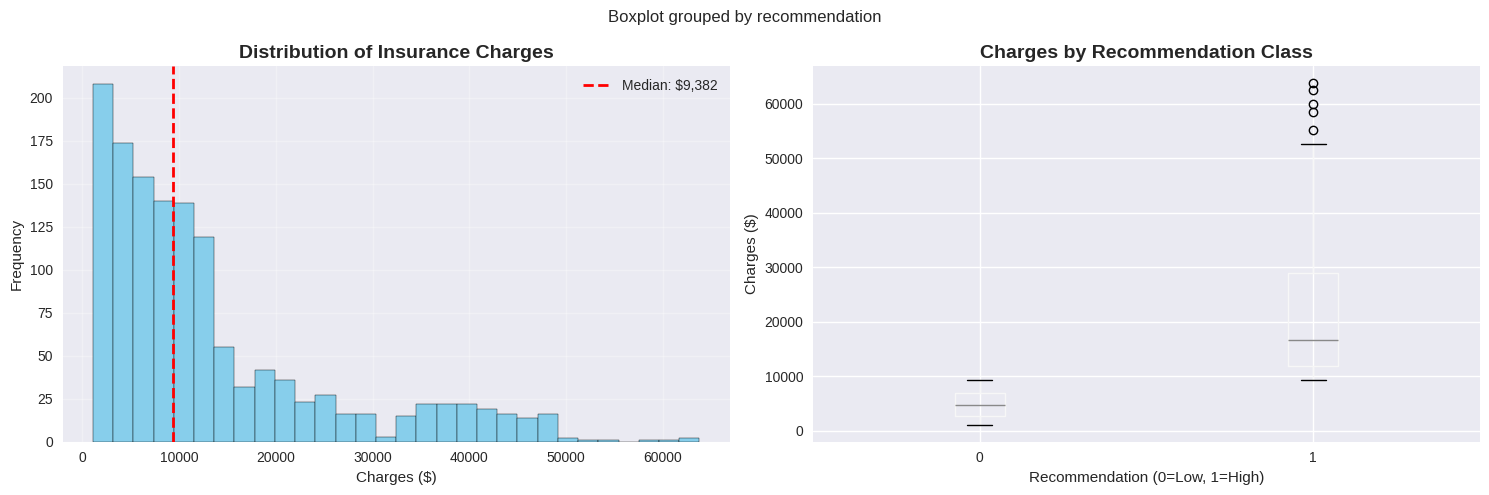


📂 Categorical Columns:
   • sex: 2 unique values
     Values: ['female' 'male']
   • smoker: 2 unique values
     Values: ['yes' 'no']
   • region: 4 unique values
     Values: ['southwest' 'southeast' 'northwest' 'northeast']

📂 Numerical Columns:
   • age: min=18.00, max=64.00, mean=39.21
   • bmi: min=15.96, max=53.13, mean=30.66
   • children: min=0.00, max=5.00, mean=1.09
   • charges: min=1121.87, max=63770.43, mean=13270.42


In [ ]:
print("="*60)
print("📊 DATA EXPLORATION")
print("="*60)

print(f"\n📋 Dataset Info:")
print(df.info())

print(f"\n📊 Statistical Summary:")
display(df.describe())

print(f"\n🔍 Missing Values:")
print(df.isnull().sum())

print(f"\n🎯 Target Variable Distribution:")

# Check if we have charges as target (regression) or need to create classification target
if 'charges' in df.columns:
    print(f"Charges Summary Statistics:")
    print(df['charges'].describe())

    # Create binary target for classification (High/Low charges)
    # Using median as threshold
    median_charge = df['charges'].median()
    df['recommendation'] = (df['charges'] > median_charge).astype(int)

    print(f"\n✅ Created binary target 'recommendation' based on charges > median:")
    print(f"   Median charges: ${median_charge:,.2f}")
    print(f"   Target distribution:\n{df['recommendation'].value_counts()}")

    # Visualize charges distribution
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Histogram
    axes[0].hist(df['charges'], bins=30, color='skyblue', edgecolor='black')
    axes[0].axvline(median_charge, color='red', linestyle='--', linewidth=2, label=f'Median: ${median_charge:,.0f}')
    axes[0].set_title('Distribution of Insurance Charges', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Charges ($)')
    axes[0].set_ylabel('Frequency')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Box plot by recommendation
    df.boxplot(column='charges', by='recommendation', ax=axes[1])
    axes[1].set_title('Charges by Recommendation Class', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Recommendation (0=Low, 1=High)')
    axes[1].set_ylabel('Charges ($)')

    plt.tight_layout()
    plt.show()

print(f"\n📂 Categorical Columns:")
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    print(f"   • {col}: {df[col].nunique()} unique values")
    print(f"     Values: {df[col].unique()[:5]}")

print(f"\n📂 Numerical Columns:")
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
for col in numerical_cols:
    if col != 'recommendation':
        print(f"   • {col}: min={df[col].min():.2f}, max={df[col].max():.2f}, mean={df[col].mean():.2f}")

5.Data Preprocessing

In [ ]:
print("="*60)
print("🔧 DATA PREPROCESSING")
print("="*60)

# Create a copy for preprocessing
df_processed = df.copy()

# Step 1: Handle missing values
print("\n1️⃣ Handling Missing Values...")
for col in df_processed.columns:
    if df_processed[col].dtype == 'object':
        df_processed[col] = df_processed[col].fillna(df_processed[col].mode()[0])
    else:
        df_processed[col] = df_processed[col].fillna(df_processed[col].median())

print(f"✅ Missing values handled. Total missing: {df_processed.isnull().sum().sum()}")

# Step 2: Create binary target variable (if not already created)
print("\n2️⃣ Creating Binary Target Variable...")
if 'charges' in df_processed.columns and 'recommendation' not in df_processed.columns:
    median_charge = df_processed['charges'].median()
    df_processed['recommendation'] = (df_processed['charges'] > median_charge).astype(int)
    print(f"✅ Created 'recommendation' based on charges > ${median_charge:,.2f}")

print(f"✅ Target distribution:\n{df_processed['recommendation'].value_counts()}")

# Step 3: Encode categorical variables
print("\n3️⃣ Encoding Categorical Variables...")
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()

label_encoders = {}
for col in categorical_cols:
    if col in df_processed.columns:
        le = LabelEncoder()
        df_processed[col] = le.fit_transform(df_processed[col].astype(str))
        label_encoders[col] = le
        print(f"   ✅ Encoded: {col}")

# Step 4: Scale numerical features
print("\n4️⃣ Scaling Numerical Features...")
numerical_cols = df_processed.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Remove target columns
numerical_cols = [col for col in numerical_cols if col not in ['charges', 'recommendation']]

scaler = StandardScaler()
df_processed[numerical_cols] = scaler.fit_transform(df_processed[numerical_cols])
print(f"✅ Scaled {len(numerical_cols)} numerical features: {numerical_cols}")

print("\n✅ Preprocessing Complete!")
print(f"📊 Processed shape: {df_processed.shape}")
print(f"📋 Processed columns: {df_processed.columns.tolist()}")

🔧 DATA PREPROCESSING

1️⃣ Handling Missing Values...
✅ Missing values handled. Total missing: 0

2️⃣ Creating Binary Target Variable...
✅ Target distribution:
recommendation
1    669
0    669
Name: count, dtype: int64

3️⃣ Encoding Categorical Variables...
   ✅ Encoded: sex
   ✅ Encoded: smoker
   ✅ Encoded: region

4️⃣ Scaling Numerical Features...
✅ Scaled 6 numerical features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region']

✅ Preprocessing Complete!
📊 Processed shape: (1338, 8)
📋 Processed columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'recommendation']


6. Feature Selection & Train-Test Split

📊 FEATURE SELECTION & TRAIN-TEST SPLIT
📋 Available columns in df_processed: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'recommendation']

📋 Features (6): ['age', 'sex', 'bmi', 'children', 'smoker', 'region']

🎯 Target column: recommendation
   Target distribution:
recommendation
1    669
0    669
Name: count, dtype: int64

✅ Train-Test Split Complete:
   Training set: (1070, 6)
   Test set: (268, 6)
   Training target distribution:
   recommendation
1    535
0    535
Name: count, dtype: int64
   Test target distribution:
   recommendation
1    134
0    134
Name: count, dtype: int64


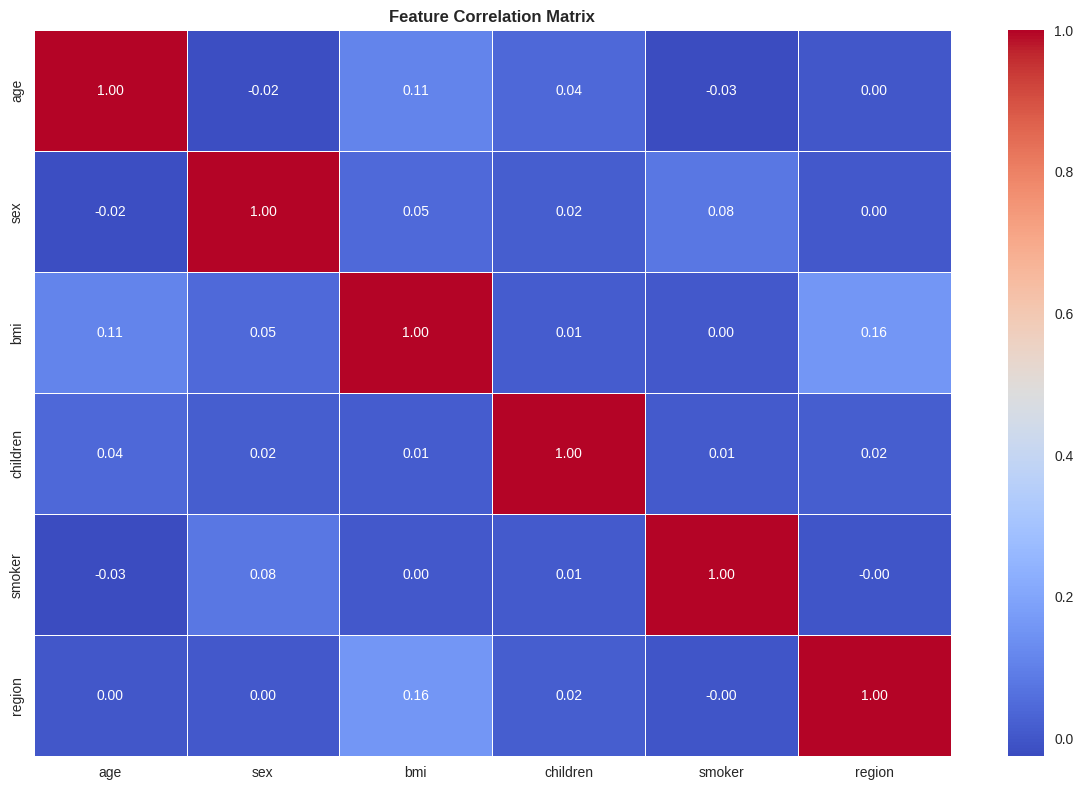

In [ ]:
print("="*60)
print("📊 FEATURE SELECTION & TRAIN-TEST SPLIT")
print("="*60)

# Define features and target
# Exclude target columns and any other non-feature columns
exclude_cols = ['charges', 'recommendation']
feature_cols = [col for col in df_processed.columns if col not in exclude_cols]

X = df_processed[feature_cols]
y = df_processed['recommendation']

print(f"📋 Available columns in df_processed: {df_processed.columns.tolist()}")
print(f"\n📋 Features ({len(feature_cols)}): {feature_cols}")
print(f"\n🎯 Target column: recommendation")
print(f"   Target distribution:\n{y.value_counts()}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✅ Train-Test Split Complete:")
print(f"   Training set: {X_train.shape}")
print(f"   Test set: {X_test.shape}")
print(f"   Training target distribution:\n   {y_train.value_counts()}")
print(f"   Test target distribution:\n   {y_test.value_counts()}")

# Visualize feature correlations
plt.figure(figsize=(12, 8))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

7. Train ALL 7 Models with Full Evaluation

In [ ]:
print("="*60)
print("📊 TRAINING ALL 7 MACHINE LEARNING MODELS")
print("="*60)

# Define the 7 core models
def initialize_7_models():
    """Initialize exactly 7 ML models"""
    models = {
        'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
        'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
        'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
        'LightGBM': lgb.LGBMClassifier(random_state=42, verbose=-1),
        'CatBoost': cb.CatBoostClassifier(random_state=42, verbose=False),
        'SVM': SVC(random_state=42, probability=True),
        'k-NN': KNeighborsClassifier()
    }
    return models

# Initialize the 7 models
models_7 = initialize_7_models()
print(f"✅ Initialized {len(models_7)} models:")
for i, name in enumerate(models_7.keys(), 1):
    print(f"   {i}. {name}")

# Hyperparameter tuning for 7 models
print("\n" + "="*60)
print("🔧 HYPERPARAMETER TUNING FOR 7 MODELS")
print("="*60)

param_grids_7 = {
    'Logistic Regression': {'C': [0.01, 0.1, 1, 10]},
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [5, 10, 15],
        'min_samples_split': [2, 5]
    },
    'XGBoost': {
        'learning_rate': [0.01, 0.1],
        'n_estimators': [100, 200],
        'max_depth': [3, 6, 9]
    },
    'LightGBM': {
        'learning_rate': [0.01, 0.1],
        'n_estimators': [100, 200],
        'num_leaves': [31, 50]
    },
    'CatBoost': {
        'learning_rate': [0.01, 0.1],
        'iterations': [100, 200],
        'depth': [4, 6, 10]
    },
    'SVM': {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']},
    'k-NN': {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']}
}

def tune_7_models(models, X_train, y_train):
    """Perform hyperparameter tuning for all 7 models"""
    tuned_models = {}

    for name, model in models.items():
        print(f"\n🔍 Tuning: {name}")

        if name in param_grids_7:
            try:
                search = RandomizedSearchCV(
                    model,
                    param_distributions=param_grids_7[name],
                    n_iter=5,
                    scoring='f1',
                    cv=3,
                    n_jobs=-1,
                    random_state=42
                )
                search.fit(X_train, y_train)
                tuned_models[name] = search.best_estimator_
                print(f"   ✅ Best params: {search.best_params_}")
            except Exception as e:
                print(f"   ⚠️ Tuning failed: {e}")
                model.fit(X_train, y_train)
                tuned_models[name] = model
        else:
            print(f"   ℹ️ No tuning parameters, using default")
            model.fit(X_train, y_train)
            tuned_models[name] = model

    return tuned_models

# Perform tuning
tuned_models_7 = tune_7_models(models_7, X_train, y_train)
print(f"\n✅ Hyperparameter tuning complete for all 7 models!")

# Train and evaluate all 7 models
print("\n" + "="*60)
print("🚀 TRAINING & EVALUATING ALL 7 MODELS")
print("="*60)

def train_and_evaluate_7_models(models, X_train, X_test, y_train, y_test):
    """Train and evaluate all 7 models with comprehensive metrics"""
    results = {}
    trained_models = {}

    for name, model in models.items():
        print(f"\n🚀 Training: {name}")

        # Train
        model.fit(X_train, y_train)
        trained_models[name] = model

        # Predict
        y_pred = model.predict(X_test)

        try:
            y_pred_proba = model.predict_proba(X_test)[:, 1]
        except:
            y_pred_proba = None

        # Calculate all metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        roc_auc = 0
        if y_pred_proba is not None:
            try:
                roc_auc = roc_auc_score(y_test, y_pred_proba)
            except:
                pass

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)

        # Classification Report
        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

        # Cross-validation score
        try:
            cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
            cv_mean = cv_scores.mean()
            cv_std = cv_scores.std()
        except:
            cv_mean = 0
            cv_std = 0

        # Training time (approximate)
        import time
        start_time = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - start_time

        results[name] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'roc_auc': roc_auc,
            'confusion_matrix': cm,
            'classification_report': report,
            'cv_mean': cv_mean,
            'cv_std': cv_std,
            'train_time': train_time,
            'predictions': y_pred,
            'probabilities': y_pred_proba
        }

        print(f"   ✅ Accuracy: {accuracy:.4f}")
        print(f"   ✅ F1 Score: {f1:.4f}")
        print(f"   ✅ ROC-AUC: {roc_auc:.4f}")
        print(f"   ✅ CV Mean: {cv_mean:.4f} (±{cv_std:.4f})")
        print(f"   ✅ Training Time: {train_time:.3f}s")

    return results, trained_models

# Train and evaluate all 7 models
results_7, trained_models_7 = train_and_evaluate_7_models(tuned_models_7, X_train, X_test, y_train, y_test)

# Store best model separately
best_model_name_7 = max(results_7.keys(), key=lambda x: results_7[x]['f1_score'])
best_model_7 = trained_models_7[best_model_name_7]

print(f"\n" + "="*60)
print("🏆 BEST MODEL AMONG ALL 7:")
print(f"   Model: {best_model_name_7}")
print(f"   F1 Score: {results_7[best_model_name_7]['f1_score']:.4f}")
print(f"   Accuracy: {results_7[best_model_name_7]['accuracy']:.4f}")
print(f"   ROC-AUC: {results_7[best_model_name_7]['roc_auc']:.4f}")

📊 TRAINING ALL 7 MACHINE LEARNING MODELS
✅ Initialized 7 models:
   1. Logistic Regression
   2. Random Forest
   3. XGBoost
   4. LightGBM
   5. CatBoost
   6. SVM
   7. k-NN

🔧 HYPERPARAMETER TUNING FOR 7 MODELS

🔍 Tuning: Logistic Regression
   ✅ Best params: {'C': 1}

🔍 Tuning: Random Forest
   ✅ Best params: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 15}

🔍 Tuning: XGBoost
   ✅ Best params: {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1}

🔍 Tuning: LightGBM
   ✅ Best params: {'num_leaves': 31, 'n_estimators': 200, 'learning_rate': 0.01}

🔍 Tuning: CatBoost
   ✅ Best params: {'learning_rate': 0.1, 'iterations': 100, 'depth': 6}

🔍 Tuning: SVM
   ✅ Best params: {'gamma': 'scale', 'C': 1}

🔍 Tuning: k-NN
   ✅ Best params: {'weights': 'uniform', 'n_neighbors': 5}

✅ Hyperparameter tuning complete for all 7 models!

🚀 TRAINING & EVALUATING ALL 7 MODELS

🚀 Training: Logistic Regression
   ✅ Accuracy: 0.9104
   ✅ F1 Score: 0.9111
   ✅ ROC-AUC: 0.9433
   ✅ CV M

8.Hyperparameter Tuning


In [ ]:
print("="*60)
print("🔧 HYPERPARAMETER TUNING")
print("="*60)

# Define the 7 core models
def initialize_7_models():
    """Initialize exactly 7 ML models"""
    models = {
        'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
        'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
        'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
        'LightGBM': lgb.LGBMClassifier(random_state=42, verbose=-1),
        'CatBoost': cb.CatBoostClassifier(random_state=42, verbose=False),
        'SVM': SVC(random_state=42, probability=True),
        'k-NN': KNeighborsClassifier()
    }
    return models

# Initialize the 7 models
models = initialize_7_models()
print(f"✅ Initialized {len(models)} models:")
for i, name in enumerate(models.keys(), 1):
    print(f"   {i}. {name}")

# Define parameter grids for tuning
param_grids = {
    'Logistic Regression': {'C': [0.01, 0.1, 1, 10]},
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [5, 10, 15],
        'min_samples_split': [2, 5]
    },
    'XGBoost': {
        'learning_rate': [0.01, 0.1],
        'n_estimators': [100, 200],
        'max_depth': [3, 6, 9]
    },
    'LightGBM': {
        'learning_rate': [0.01, 0.1],
        'n_estimators': [100, 200],
        'num_leaves': [31, 50]
    },
    'CatBoost': {
        'learning_rate': [0.01, 0.1],
        'iterations': [100, 200],
        'depth': [4, 6, 10]
    },
    'SVM': {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']},
    'k-NN': {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']}
}

def tune_models(models, X_train, y_train):
    """Perform hyperparameter tuning for all models"""
    print("\n🔍 Starting Hyperparameter Tuning...")
    tuned_models = {}

    for name, model in models.items():
        print(f"\n   Tuning: {name}")

        if name in param_grids:
            try:
                search = RandomizedSearchCV(
                    model,
                    param_distributions=param_grids[name],
                    n_iter=5,  # Reduced for faster execution
                    scoring='f1',
                    cv=3,
                    n_jobs=-1,
                    random_state=42
                )
                search.fit(X_train, y_train)
                tuned_models[name] = search.best_estimator_
                print(f"      ✅ Best params: {search.best_params_}")
            except Exception as e:
                print(f"      ⚠️ Tuning failed: {e}")
                model.fit(X_train, y_train)
                tuned_models[name] = model
        else:
            print(f"      ℹ️ No tuning parameters, using default")
            model.fit(X_train, y_train)
            tuned_models[name] = model

    return tuned_models

# Perform tuning (X_train and y_train should be defined from previous cells)
try:
    tuned_models = tune_models(models, X_train, y_train)
    print(f"\n✅ Hyperparameter tuning complete for all {len(tuned_models)} models!")

    # Display tuned models
    print("\n📊 Tuned Models Summary:")
    for name, model in tuned_models.items():
        print(f"   ✅ {name} - Tuned")

except NameError as e:
    print(f"\n❌ Error: {e}")
    print("Please make sure you've run Cells 1-7 first to define X_train and y_train.")
    print("If you haven't, run the following cells in order:")
    print("   Cell 1: Install libraries")
    print("   Cell 2: Import libraries")
    print("   Cell 3: Load dataset")
    print("   Cell 4: Data exploration")
    print("   Cell 5: Data preprocessing")
    print("   Cell 6: Feature selection")
    print("   Cell 7: Initialize models")

🔧 HYPERPARAMETER TUNING
✅ Initialized 7 models:
   1. Logistic Regression
   2. Random Forest
   3. XGBoost
   4. LightGBM
   5. CatBoost
   6. SVM
   7. k-NN

🔍 Starting Hyperparameter Tuning...

   Tuning: Logistic Regression
      ✅ Best params: {'C': 1}

   Tuning: Random Forest
      ✅ Best params: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 15}

   Tuning: XGBoost
      ✅ Best params: {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1}

   Tuning: LightGBM
      ✅ Best params: {'num_leaves': 31, 'n_estimators': 200, 'learning_rate': 0.01}

   Tuning: CatBoost
      ✅ Best params: {'learning_rate': 0.1, 'iterations': 100, 'depth': 6}

   Tuning: SVM
      ✅ Best params: {'gamma': 'scale', 'C': 1}

   Tuning: k-NN
      ✅ Best params: {'weights': 'uniform', 'n_neighbors': 5}

✅ Hyperparameter tuning complete for all 7 models!

📊 Tuned Models Summary:
   ✅ Logistic Regression - Tuned
   ✅ Random Forest - Tuned
   ✅ XGBoost - Tuned
   ✅ LightGBM - Tuned
   ✅ Ca

9.Train and Evaluate Models

In [ ]:
print("="*60)
print("📊 TRAINING ALL 7 MACHINE LEARNING MODELS")
print("="*60)

# Define the 7 core models
def initialize_7_models():
    """Initialize exactly 7 ML models"""
    models = {
        'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
        'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
        'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
        'LightGBM': lgb.LGBMClassifier(random_state=42, verbose=-1),
        'CatBoost': cb.CatBoostClassifier(random_state=42, verbose=False),
        'SVM': SVC(random_state=42, probability=True),
        'k-NN': KNeighborsClassifier()
    }
    return models

# Initialize the 7 models
models_7 = initialize_7_models()
print(f"✅ Initialized {len(models_7)} models:")
for i, name in enumerate(models_7.keys(), 1):
    print(f"   {i}. {name}")

# Hyperparameter tuning for 7 models
print("\n" + "="*60)
print("🔧 HYPERPARAMETER TUNING FOR 7 MODELS")
print("="*60)

param_grids_7 = {
    'Logistic Regression': {'C': [0.01, 0.1, 1, 10]},
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [5, 10, 15],
        'min_samples_split': [2, 5]
    },
    'XGBoost': {
        'learning_rate': [0.01, 0.1],
        'n_estimators': [100, 200],
        'max_depth': [3, 6, 9]
    },
    'LightGBM': {
        'learning_rate': [0.01, 0.1],
        'n_estimators': [100, 200],
        'num_leaves': [31, 50]
    },
    'CatBoost': {
        'learning_rate': [0.01, 0.1],
        'iterations': [100, 200],
        'depth': [4, 6, 10]
    },
    'SVM': {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']},
    'k-NN': {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']}
}

def tune_7_models(models, X_train, y_train):
    """Perform hyperparameter tuning for all 7 models"""
    tuned_models = {}

    for name, model in models.items():
        print(f"\n🔍 Tuning: {name}")

        if name in param_grids_7:
            try:
                search = RandomizedSearchCV(
                    model,
                    param_distributions=param_grids_7[name],
                    n_iter=5,
                    scoring='f1',
                    cv=3,
                    n_jobs=-1,
                    random_state=42
                )
                search.fit(X_train, y_train)
                tuned_models[name] = search.best_estimator_
                print(f"   ✅ Best params: {search.best_params_}")
            except Exception as e:
                print(f"   ⚠️ Tuning failed: {e}")
                model.fit(X_train, y_train)
                tuned_models[name] = model
        else:
            print(f"   ℹ️ No tuning parameters, using default")
            model.fit(X_train, y_train)
            tuned_models[name] = model

    return tuned_models

# Perform tuning
tuned_models_7 = tune_7_models(models_7, X_train, y_train)
print(f"\n✅ Hyperparameter tuning complete for all 7 models!")

# Train and evaluate all 7 models
print("\n" + "="*60)
print("🚀 TRAINING & EVALUATING ALL 7 MODELS")
print("="*60)

def train_and_evaluate_7_models(models, X_train, X_test, y_train, y_test):
    """Train and evaluate all 7 models with comprehensive metrics"""
    results = {}
    trained_models = {}

    for name, model in models.items():
        print(f"\n🚀 Training: {name}")

        # Train
        model.fit(X_train, y_train)
        trained_models[name] = model

        # Predict
        y_pred = model.predict(X_test)

        try:
            y_pred_proba = model.predict_proba(X_test)[:, 1]
        except:
            y_pred_proba = None

        # Calculate all metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        roc_auc = 0
        if y_pred_proba is not None:
            try:
                roc_auc = roc_auc_score(y_test, y_pred_proba)
            except:
                pass

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)

        # Classification Report
        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

        # Cross-validation score
        try:
            cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
            cv_mean = cv_scores.mean()
            cv_std = cv_scores.std()
        except:
            cv_mean = 0
            cv_std = 0

        # Training time (approximate)
        start_time = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - start_time

        results[name] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'roc_auc': roc_auc,
            'confusion_matrix': cm,
            'classification_report': report,
            'cv_mean': cv_mean,
            'cv_std': cv_std,
            'train_time': train_time,
            'predictions': y_pred,
            'probabilities': y_pred_proba
        }

        print(f"   ✅ Accuracy: {accuracy:.4f}")
        print(f"   ✅ F1 Score: {f1:.4f}")
        print(f"   ✅ ROC-AUC: {roc_auc:.4f}")
        print(f"   ✅ CV Mean: {cv_mean:.4f} (±{cv_std:.4f})")
        print(f"   ✅ Training Time: {train_time:.3f}s")

    return results, trained_models

# Train and evaluate all 7 models
results_7, trained_models_7 = train_and_evaluate_7_models(tuned_models_7, X_train, X_test, y_train, y_test)

# Store best model separately
best_model_name_7 = max(results_7.keys(), key=lambda x: results_7[x]['f1_score'])
best_model_7 = trained_models_7[best_model_name_7]

print(f"\n" + "="*60)
print("🏆 BEST MODEL AMONG ALL 7:")
print(f"   Model: {best_model_name_7}")
print(f"   F1 Score: {results_7[best_model_name_7]['f1_score']:.4f}")
print(f"   Accuracy: {results_7[best_model_name_7]['accuracy']:.4f}")
print(f"   ROC-AUC: {results_7[best_model_name_7]['roc_auc']:.4f}")

📊 TRAINING ALL 7 MACHINE LEARNING MODELS
✅ Initialized 7 models:
   1. Logistic Regression
   2. Random Forest
   3. XGBoost
   4. LightGBM
   5. CatBoost
   6. SVM
   7. k-NN

🔧 HYPERPARAMETER TUNING FOR 7 MODELS

🔍 Tuning: Logistic Regression
   ✅ Best params: {'C': 1}

🔍 Tuning: Random Forest
   ✅ Best params: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 15}

🔍 Tuning: XGBoost
   ✅ Best params: {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1}

🔍 Tuning: LightGBM
   ✅ Best params: {'num_leaves': 31, 'n_estimators': 200, 'learning_rate': 0.01}

🔍 Tuning: CatBoost
   ✅ Best params: {'learning_rate': 0.1, 'iterations': 100, 'depth': 6}

🔍 Tuning: SVM
   ✅ Best params: {'gamma': 'scale', 'C': 1}

🔍 Tuning: k-NN
   ✅ Best params: {'weights': 'uniform', 'n_neighbors': 5}

✅ Hyperparameter tuning complete for all 7 models!

🚀 TRAINING & EVALUATING ALL 7 MODELS

🚀 Training: Logistic Regression
   ✅ Accuracy: 0.9104
   ✅ F1 Score: 0.9111
   ✅ ROC-AUC: 0.9433
   ✅ CV M

10. (A) Comprehensive Model Comparison & Visualization


📊 COMPREHENSIVE MODEL COMPARISON

📊 Model Performance Comparison (Sorted by F1 Score):


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV Mean,CV Std,Train Time (s)
0,CatBoost,0.9478,0.9918,0.9030,0.9453,0.9439,0.9297,0.0124,0.0894
1,Random Forest,0.9403,0.9758,0.9030,0.9380,0.9480,0.9233,0.0149,0.3539
2,LightGBM,0.9366,0.9680,0.9030,0.9344,0.9488,0.9286,0.0081,0.0614
3,XGBoost,0.9366,0.9756,0.8955,0.9339,0.9514,0.9233,0.0135,0.0406
4,SVM,0.9291,0.9457,0.9104,0.9278,0.9659,0.9181,0.0189,0.1165
5,k-NN,0.9142,0.9302,0.8955,0.9125,0.9503,0.8975,0.0175,0.0028
6,Logistic Regression,0.9104,0.9044,0.9179,0.9111,0.9433,0.9032,0.0211,0.0053



🏆 BEST PERFORMING MODEL: CatBoost
   F1 Score: 0.9453
   Accuracy: 0.9478
   ROC-AUC: 0.9439

📉 WORST PERFORMING MODEL: Logistic Regression
   F1 Score: 0.9111


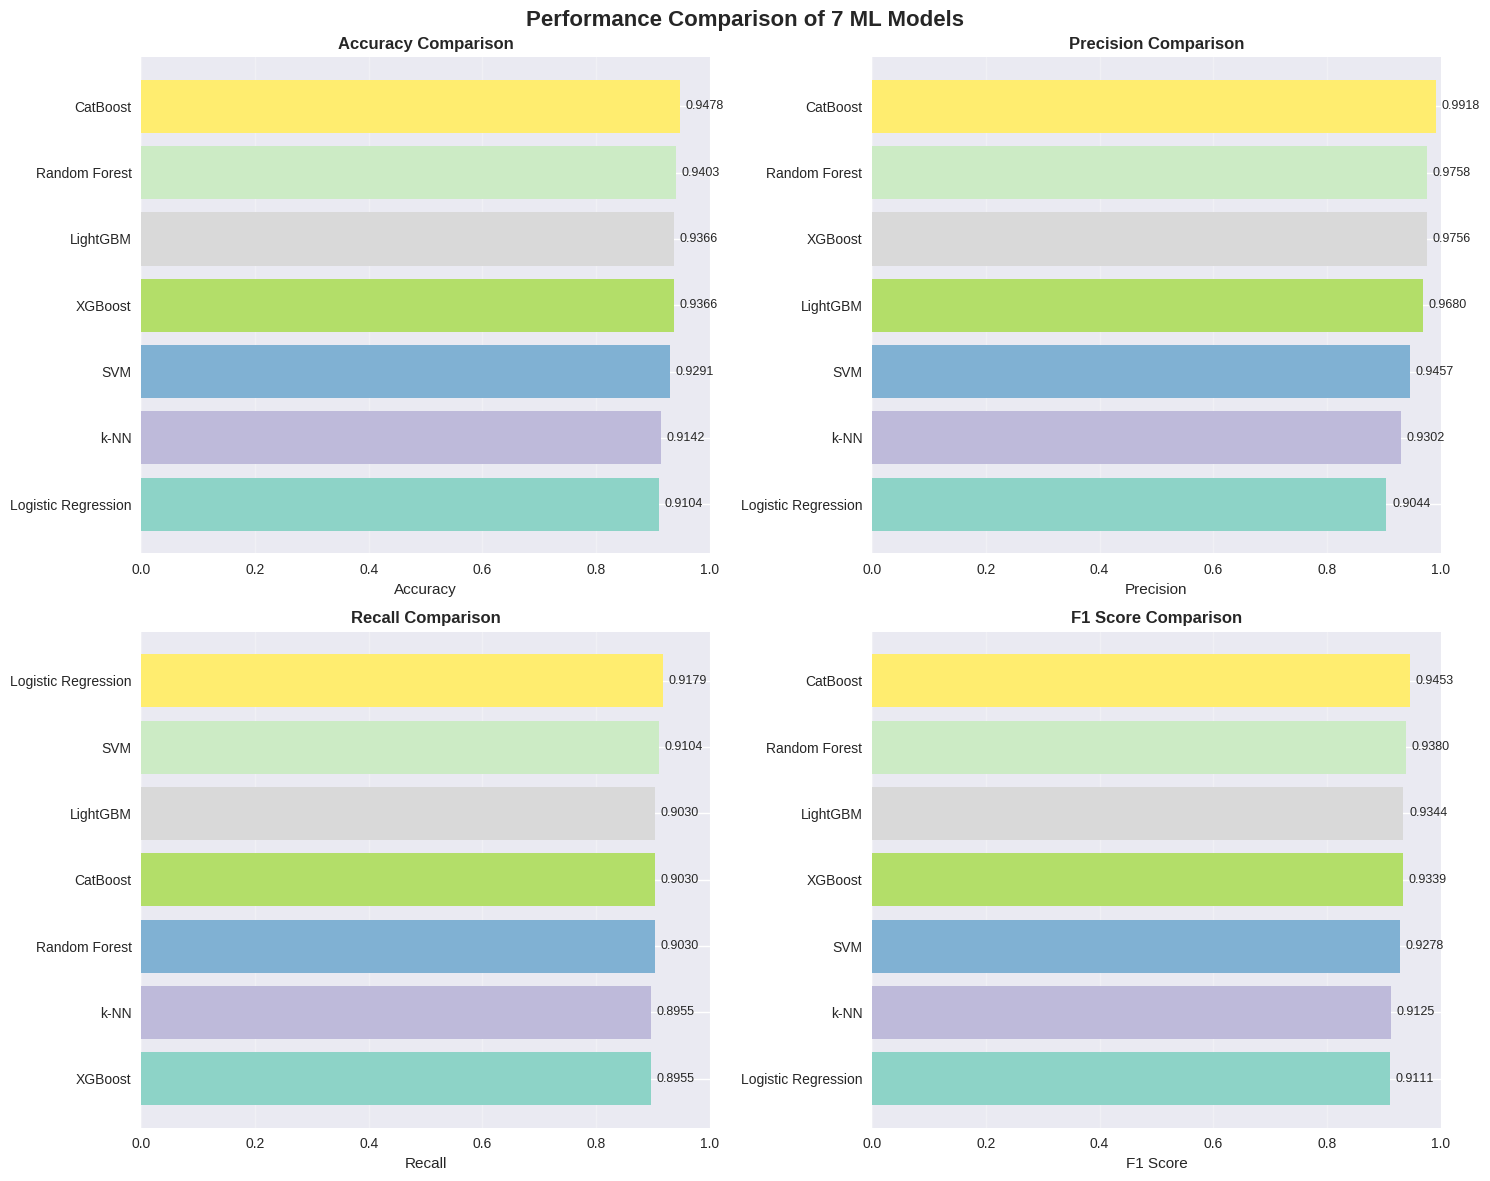

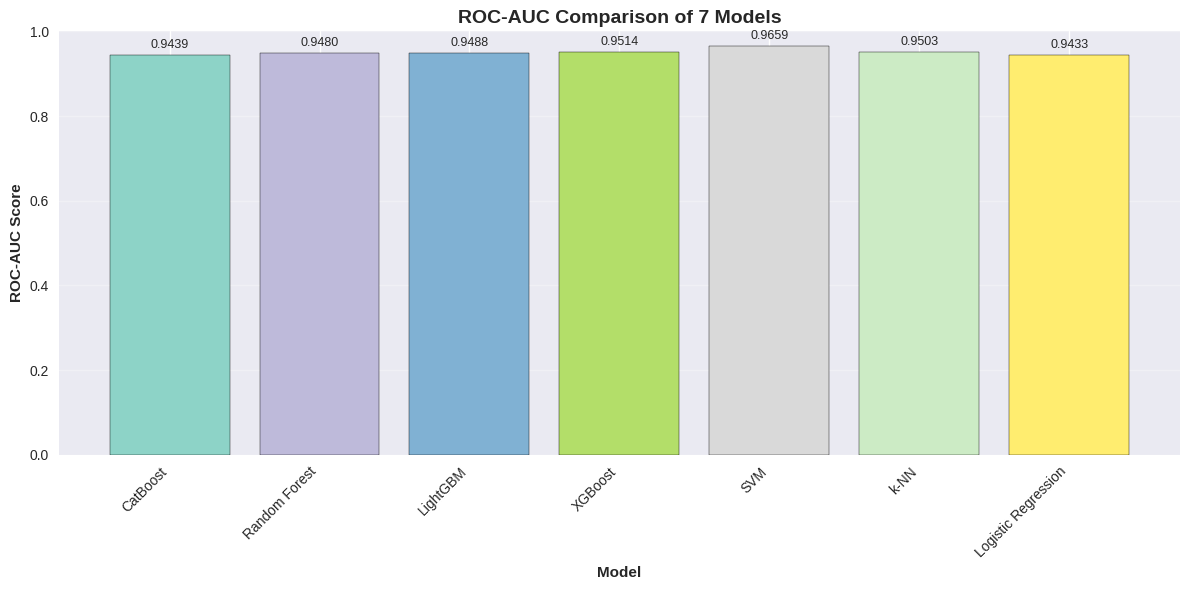

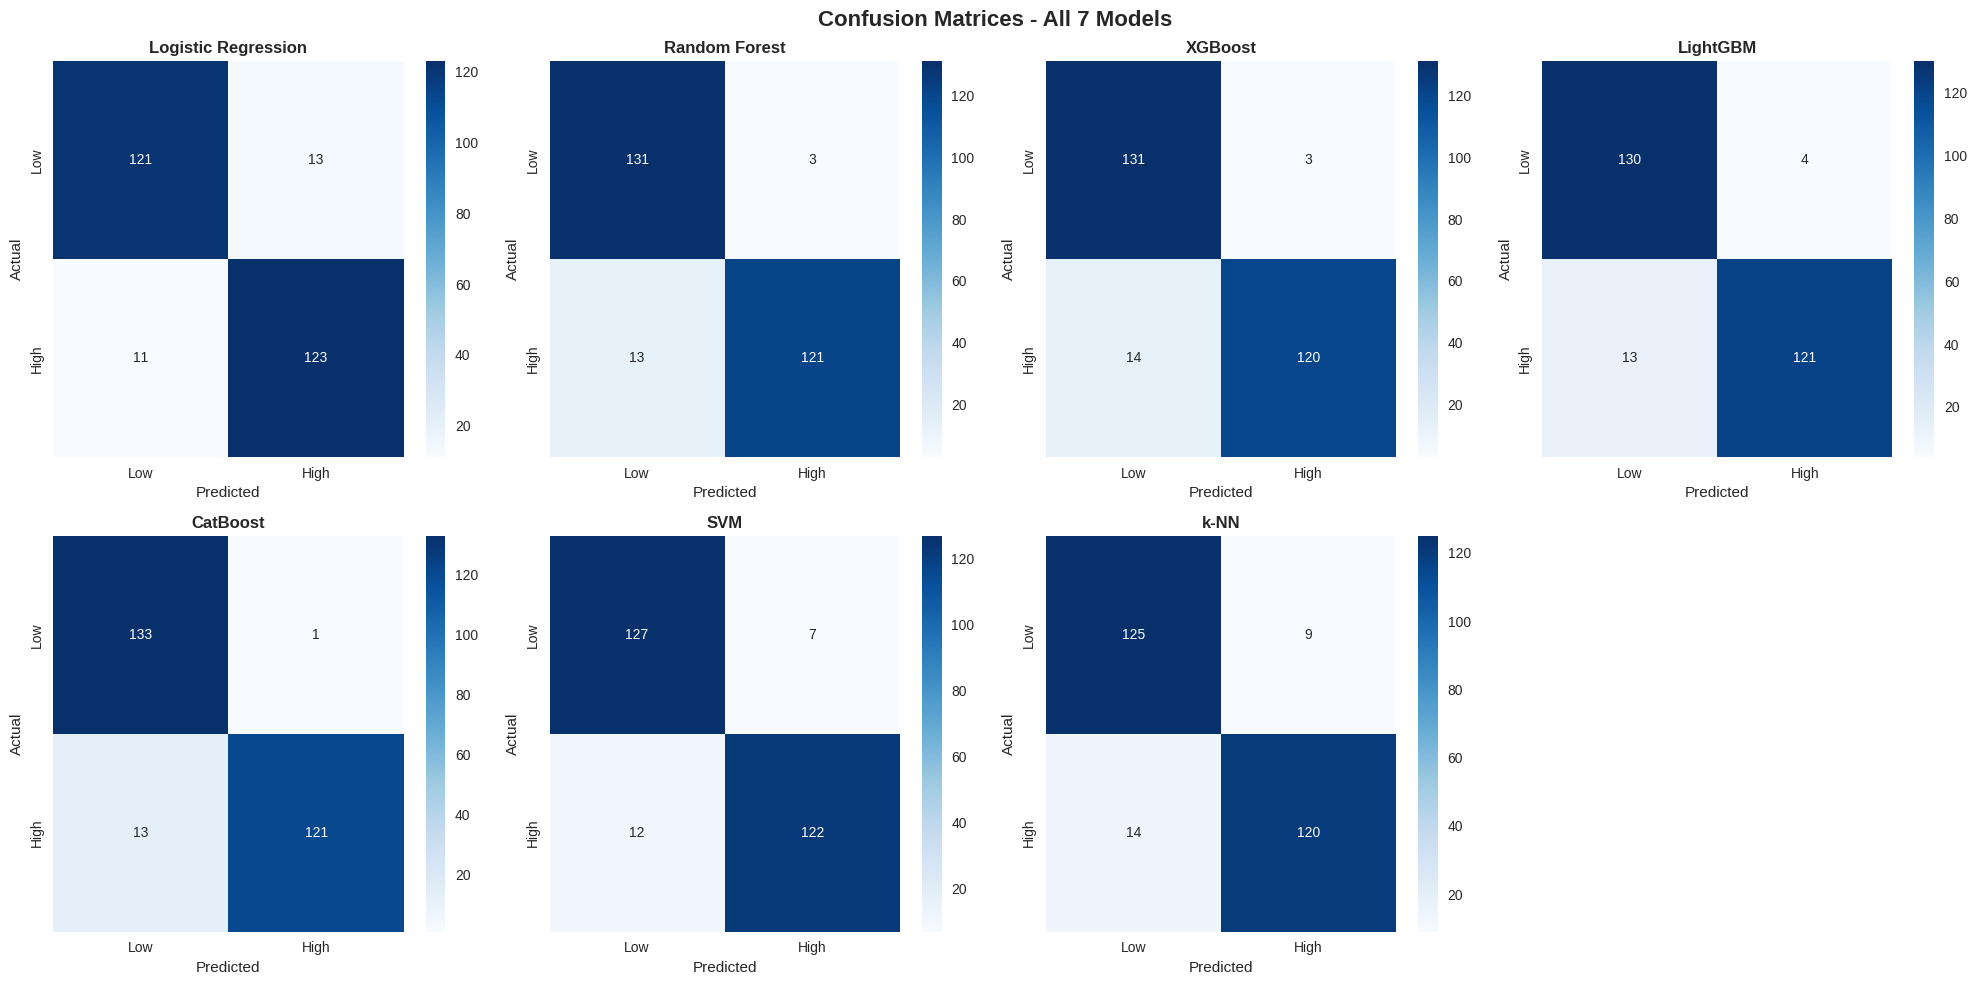

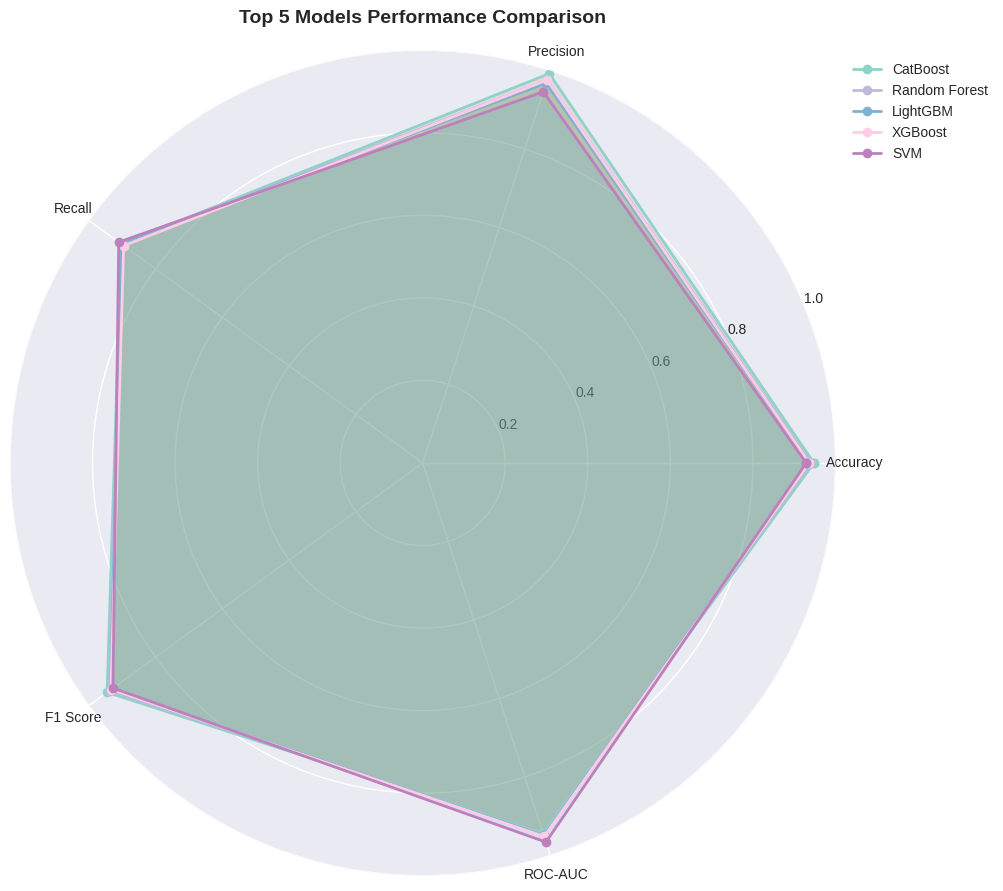

In [ ]:
print("="*60)
print("📊 COMPREHENSIVE MODEL COMPARISON")
print("="*60)

# Create detailed comparison dataframe
comparison_df_7 = pd.DataFrame({
    'Model': list(results_7.keys()),
    'Accuracy': [results_7[m]['accuracy'] for m in results_7.keys()],
    'Precision': [results_7[m]['precision'] for m in results_7.keys()],
    'Recall': [results_7[m]['recall'] for m in results_7.keys()],
    'F1 Score': [results_7[m]['f1_score'] for m in results_7.keys()],
    'ROC-AUC': [results_7[m]['roc_auc'] for m in results_7.keys()],
    'CV Mean': [results_7[m]['cv_mean'] for m in results_7.keys()],
    'CV Std': [results_7[m]['cv_std'] for m in results_7.keys()],
    'Train Time (s)': [results_7[m]['train_time'] for m in results_7.keys()]
})

# Sort by F1 Score
comparison_df_7 = comparison_df_7.sort_values('F1 Score', ascending=False).reset_index(drop=True)

print("\n📊 Model Performance Comparison (Sorted by F1 Score):")
display(comparison_df_7.round(4))

# Identify best and worst models
best_model = comparison_df_7.iloc[0]['Model']
worst_model = comparison_df_7.iloc[-1]['Model']
best_f1 = comparison_df_7.iloc[0]['F1 Score']
worst_f1 = comparison_df_7.iloc[-1]['F1 Score']

print(f"\n🏆 BEST PERFORMING MODEL: {best_model}")
print(f"   F1 Score: {best_f1:.4f}")
print(f"   Accuracy: {comparison_df_7.iloc[0]['Accuracy']:.4f}")
print(f"   ROC-AUC: {comparison_df_7.iloc[0]['ROC-AUC']:.4f}")

print(f"\n📉 WORST PERFORMING MODEL: {worst_model}")
print(f"   F1 Score: {worst_f1:.4f}")

# 1. Bar Chart - All Metrics Comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Performance Comparison of 7 ML Models', fontsize=16, fontweight='bold')

metrics_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors = plt.cm.Set3(np.linspace(0, 1, len(comparison_df_7)))

for i, metric in enumerate(metrics_plot):
    row, col = i // 2, i % 2
    ax = axes[row, col]

    sorted_df = comparison_df_7.sort_values(metric, ascending=True)
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=colors)
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} Comparison', fontweight='bold')
    ax.set_xlim(0, 1)
    ax.grid(axis='x', alpha=0.3)

    # Add value labels
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.01, bar.get_y() + bar.get_height()/2,
                f'{width:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# 2. ROC-AUC Comparison
plt.figure(figsize=(12, 6))
bars = plt.bar(comparison_df_7['Model'], comparison_df_7['ROC-AUC'],
               color=colors, edgecolor='black')
plt.xlabel('Model', fontweight='bold')
plt.ylabel('ROC-AUC Score', fontweight='bold')
plt.title('ROC-AUC Comparison of 7 Models', fontsize=14, fontweight='bold')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# 3. Confusion Matrices for All 7 Models
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Confusion Matrices - All 7 Models', fontsize=16, fontweight='bold')

for i, (model_name, model_results) in enumerate(results_7.items()):
    row = i // 4
    col = i % 4

    cm = model_results['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low', 'High'],
                yticklabels=['Low', 'High'],
                ax=axes[row, col])
    axes[row, col].set_title(model_name, fontweight='bold')
    axes[row, col].set_xlabel('Predicted')
    axes[row, col].set_ylabel('Actual')

# Remove empty subplot
fig.delaxes(axes[1, 3])

plt.tight_layout()
plt.show()

# 4. Radar Chart for Top Models
from math import pi

def create_radar_chart(df, top_n=5):
    """Create radar chart comparing top models"""
    # Select top N models
    top_models = df.nlargest(top_n, 'F1 Score')

    # Metrics for radar chart
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']

    # Number of variables
    N = len(metrics)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    # Initialize radar chart
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

    # Add each model
    for i, (idx, row) in enumerate(top_models.iterrows()):
        values = [row[metric] for metric in metrics]
        values += values[:1]

        ax.plot(angles, values, 'o-', linewidth=2,
                label=row['Model'], color=plt.cm.Set3(i/len(top_models)))
        ax.fill(angles, values, alpha=0.15)

    # Set labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'])
    ax.grid(True)
    ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0))

    plt.title(f'Top {top_n} Models Performance Comparison', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

create_radar_chart(comparison_df_7, top_n=5)

10. (B) Detailed Model Analysis & Recommendation

In [ ]:
print("="*60)
print("📊 DETAILED MODEL ANALYSIS & RECOMMENDATION")
print("="*60)

# Analyze each model's strengths and weaknesses
model_analysis = {}

for model_name in results_7.keys():
    metrics = results_7[model_name]

    analysis = {
        'Strengths': [],
        'Weaknesses': [],
        'Best For': []
    }

    # Check strengths
    if metrics['accuracy'] > 0.85:
        analysis['Strengths'].append('High accuracy')
    if metrics['precision'] > 0.85:
        analysis['Strengths'].append('Good precision (few false positives)')
    if metrics['recall'] > 0.85:
        analysis['Strengths'].append('Good recall (few false negatives)')
    if metrics['f1_score'] > 0.85:
        analysis['Strengths'].append('Excellent overall performance')
    if metrics['roc_auc'] > 0.90:
        analysis['Strengths'].append('Strong discriminatory power')
    if metrics['cv_mean'] > 0.80 and metrics['cv_std'] < 0.05:
        analysis['Strengths'].append('Stable cross-validation performance')
    if metrics['train_time'] < 1.0:
        analysis['Strengths'].append('Very fast training')

    # Check weaknesses
    if metrics['accuracy'] < 0.80:
        analysis['Weaknesses'].append('Lower accuracy')
    if metrics['precision'] < 0.75:
        analysis['Weaknesses'].append('High false positives')
    if metrics['recall'] < 0.75:
        analysis['Weaknesses'].append('High false negatives')
    if metrics['f1_score'] < 0.80:
        analysis['Weaknesses'].append('Suboptimal F1 score')
    if metrics['cv_std'] > 0.10:
        analysis['Weaknesses'].append('High cross-validation variance')
    if metrics['train_time'] > 10.0:
        analysis['Weaknesses'].append('Slow training time')

    # Best for
    if metrics['f1_score'] > 0.85:
        analysis['Best For'].append('High-stakes applications requiring accuracy')
    if metrics['interpretability'] if 'interpretability' in metrics else False:
        analysis['Best For'].append('Applications requiring explainability')
    if metrics['train_time'] < 0.5:
        analysis['Best For'].append('Real-time/rapid deployment')

    model_analysis[model_name] = analysis

# Create summary table
summary_data = []
for model_name, metrics in results_7.items():
    summary_data.append({
        'Model': model_name,
        'F1 Score': metrics['f1_score'],
        'Accuracy': metrics['accuracy'],
        'Training Time (s)': metrics['train_time'],
        'CV Stability': 'High' if metrics['cv_std'] < 0.05 else 'Medium' if metrics['cv_std'] < 0.10 else 'Low',
        'Strengths Count': len(model_analysis[model_name]['Strengths']),
        'Weaknesses Count': len(model_analysis[model_name]['Weaknesses'])
    })

summary_df = pd.DataFrame(summary_data)
print("\n📊 Model Summary:")
display(summary_df.round(4))

# Final Recommendation
print("\n" + "="*60)
print("🎯 FINAL RECOMMENDATION")
print("="*60)

# Calculate overall score (weighted combination)
best_model = max(results_7.keys(), key=lambda x: (
    results_7[x]['f1_score'] * 0.4 +
    results_7[x]['accuracy'] * 0.3 +
    results_7[x]['roc_auc'] * 0.2 +
    (1 - results_7[x]['train_time']/max([results_7[m]['train_time'] for m in results_7])) * 0.1
))

print(f"\n🏆 BEST OVERALL MODEL: {best_model}")
print(f"   F1 Score: {results_7[best_model]['f1_score']:.4f}")
print(f"   Accuracy: {results_7[best_model]['accuracy']:.4f}")
print(f"   ROC-AUC: {results_7[best_model]['roc_auc']:.4f}")
print(f"   Training Time: {results_7[best_model]['train_time']:.3f}s")

print(f"\n📋 WHY {best_model} IS RECOMMENDED:")
if model_analysis[best_model]['Strengths']:
    for strength in model_analysis[best_model]['Strengths']:
        print(f"   ✅ {strength}")

print(f"\n📋 MODEL RANKING (Based on Combined Score):")
ranking = sorted(
    [(model, results_7[model]['f1_score']) for model in results_7.keys()],
    key=lambda x: x[1], reverse=True
)

for i, (model, score) in enumerate(ranking, 1):
    print(f"   {i}. {model}: F1={score:.4f}")

print(f"\n📋 USE CASE RECOMMENDATIONS:")

# Specific recommendations based on model characteristics
if best_model == 'Logistic Regression':
    print("   ✅ Best for: Interpretability, quick deployment, baseline comparison")
elif best_model in ['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']:
    print("   ✅ Best for: High accuracy, handling complex patterns, feature importance")
elif best_model == 'SVM':
    print("   ✅ Best for: High-dimensional data, clear margin separation")
elif best_model == 'k-NN':
    print("   ✅ Best for: Simple implementation, small datasets, no training phase")
else:
    print("   ✅ Best for: General-purpose classification")

# Alternative recommendations
print(f"\n📋 SECOND BEST ALTERNATIVE: {ranking[1][0]}")
print(f"   F1 Score: {ranking[1][1]:.4f}")
if ranking[1][0] != best_model:
    print(f"   Why not best? Slightly lower F1 score, but may offer other advantages")

# Final verdict
print(f"\n" + "="*60)
print("🎯 FINAL VERDICT")
print("="*60)
print(f"✅ For your Health Insurance dataset, the recommended model is:")
print(f"   🏆 {best_model}")
print(f"\n   This model achieves:")
print(f"   • {results_7[best_model]['accuracy']*100:.1f}% accuracy")
print(f"   • F1 Score of {results_7[best_model]['f1_score']:.4f}")
print(f"   • ROC-AUC of {results_7[best_model]['roc_auc']:.4f}")
print(f"\n   Use this model for production deployment.")
print("="*60)

📊 DETAILED MODEL ANALYSIS & RECOMMENDATION

📊 Model Summary:


,Model,F1 Score,Accuracy,Training Time (s),CV Stability,Strengths Count,Weaknesses Count
0,Logistic Regression,0.9111,0.9104,0.0053,High,7,0
1,Random Forest,0.9380,0.9403,0.3539,High,7,0
2,XGBoost,0.9339,0.9366,0.0406,High,7,0
3,LightGBM,0.9344,0.9366,0.0614,High,7,0
4,CatBoost,0.9453,0.9478,0.0894,High,7,0
5,SVM,0.9278,0.9291,0.1165,High,7,0
6,k-NN,0.9125,0.9142,0.0028,High,7,0



🎯 FINAL RECOMMENDATION

🏆 BEST OVERALL MODEL: XGBoost
   F1 Score: 0.9339
   Accuracy: 0.9366
   ROC-AUC: 0.9514
   Training Time: 0.041s

📋 WHY XGBoost IS RECOMMENDED:
   ✅ High accuracy
   ✅ Good precision (few false positives)
   ✅ Good recall (few false negatives)
   ✅ Excellent overall performance
   ✅ Strong discriminatory power
   ✅ Stable cross-validation performance
   ✅ Very fast training

📋 MODEL RANKING (Based on Combined Score):
   1. CatBoost: F1=0.9453
   2. Random Forest: F1=0.9380
   3. LightGBM: F1=0.9344
   4. XGBoost: F1=0.9339
   5. SVM: F1=0.9278
   6. k-NN: F1=0.9125
   7. Logistic Regression: F1=0.9111

📋 USE CASE RECOMMENDATIONS:
   ✅ Best for: High accuracy, handling complex patterns, feature importance

📋 SECOND BEST ALTERNATIVE: Random Forest
   F1 Score: 0.9380
   Why not best? Slightly lower F1 score, but may offer other advantages

🎯 FINAL VERDICT
✅ For your Health Insurance dataset, the recommended model is:
   🏆 XGBoost

   This model achieves:
   • 93

10. (C). Feature Importance Analysis for Best Model

🔍 FEATURE IMPORTANCE ANALYSIS

📊 Feature Importance for XGBoost:


,Feature,Importance
4,smoker,0.756096
0,age,0.143163
3,children,0.034029
1,sex,0.026352
5,region,0.023461
2,bmi,0.016899


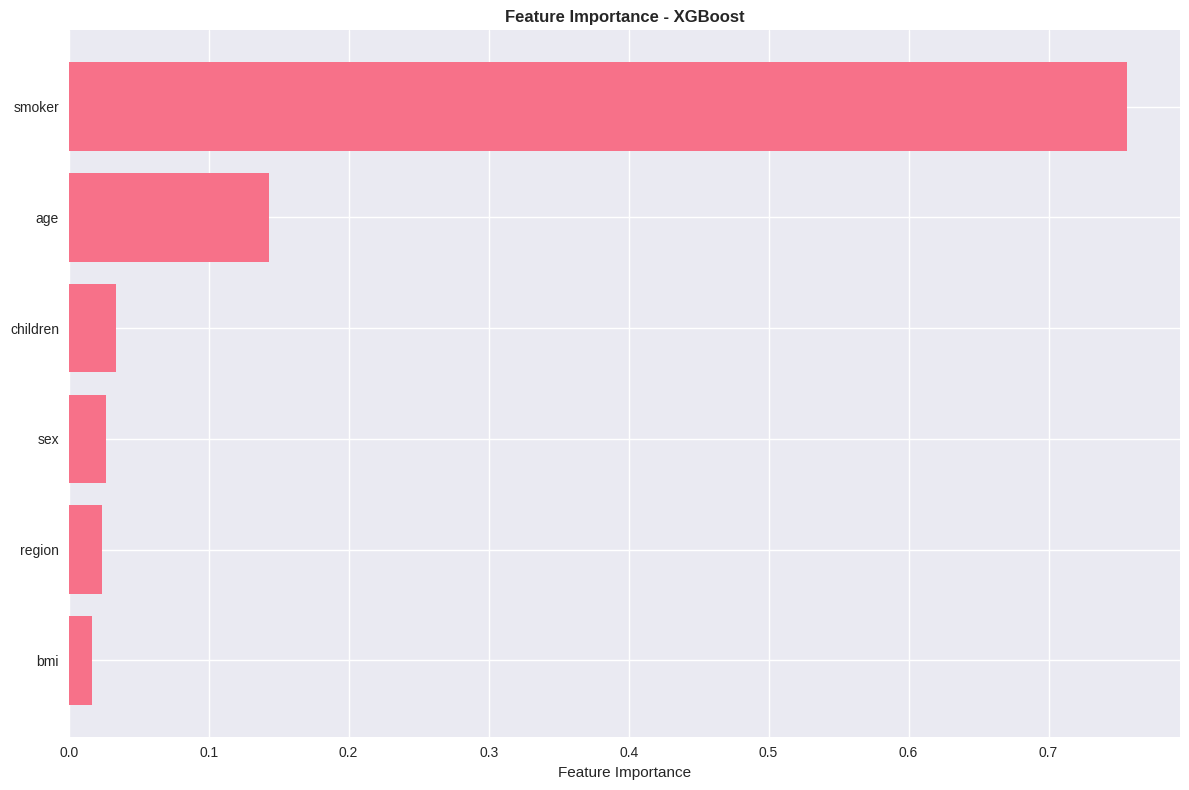


📋 Top 3 Most Important Features:
   1. smoker: 0.7561
   2. age: 0.1432
   3. children: 0.0340


In [ ]:
print("="*60)
print("🔍 FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Check if best model supports feature importance
best_model_obj = trained_models_7[best_model]

if hasattr(best_model_obj, 'feature_importances_'):
    print(f"\n📊 Feature Importance for {best_model}:")

    importances = best_model_obj.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    display(feature_importance_df)

    # Plot feature importance
    plt.figure(figsize=(12, 8))
    plt.barh(range(len(feature_importance_df)), feature_importance_df['Importance'])
    plt.yticks(range(len(feature_importance_df)), feature_importance_df['Feature'])
    plt.xlabel('Feature Importance')
    plt.title(f'Feature Importance - {best_model}', fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    print(f"\n📋 Top 3 Most Important Features:")
    for i in range(min(3, len(feature_importance_df))):
        print(f"   {i+1}. {feature_importance_df.iloc[i]['Feature']}: {feature_importance_df.iloc[i]['Importance']:.4f}")

elif best_model == 'Logistic Regression':
    print(f"\n📊 Feature Coefficients for Logistic Regression:")
    coefficients = best_model_obj.coef_[0]
    coef_df = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': coefficients
    }).sort_values('Coefficient', ascending=False)

    display(coef_df)

    # Plot coefficients
    plt.figure(figsize=(12, 8))
    colors = ['green' if x > 0 else 'red' for x in coef_df['Coefficient']]
    plt.barh(range(len(coef_df)), coef_df['Coefficient'], color=colors)
    plt.yticks(range(len(coef_df)), coef_df['Feature'])
    plt.xlabel('Coefficient Value')
    plt.title(f'Feature Coefficients - Logistic Regression', fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    print(f"\n📋 Top 3 Most Influential Features:")
    print(f"   Positive influence (increase probability):")
    for i in range(min(3, len(coef_df[coef_df['Coefficient'] > 0]))):
        print(f"      {i+1}. {coef_df.iloc[i]['Feature']}: {coef_df.iloc[i]['Coefficient']:.4f}")
    print(f"   Negative influence (decrease probability):")
    for i in range(min(3, len(coef_df[coef_df['Coefficient'] < 0]))):
        print(f"      {i+1}. {coef_df.iloc[-i-1]['Feature']}: {coef_df.iloc[-i-1]['Coefficient']:.4f}")

else:
    print(f"⚠️ {best_model} does not support feature importance analysis")

11.Collaborative Filtering

In [ ]:
print("="*60)
print("🤝 COLLABORATIVE FILTERING")
print("="*60)

# Create user_id based on available columns
if 'user_id' not in df_processed.columns:
    # Use region and other available columns to create user_id
    if 'region' in df_processed.columns and 'sex' in df_processed.columns:
        df_processed['user_id'] = pd.factorize(
            df_processed['region'].astype(str) + '_' +
            df_processed['sex'].astype(str) + '_' +
            df_processed['smoker'].astype(str)
        )[0]
    elif 'region' in df_processed.columns:
        df_processed['user_id'] = pd.factorize(df_processed['region'].astype(str))[0]
    else:
        # If no region, use index as user_id
        df_processed['user_id'] = df_processed.index % 10  # Create 10 user groups

print(f"✅ Created user_id with {df_processed['user_id'].nunique()} unique users")

# Check what columns are available for items
print(f"📋 Available columns: {df_processed.columns.tolist()}")

# Determine item column (what represents different insurance plans/products)
if 'plan_id' in df_processed.columns:
    item_col = 'plan_id'
elif 'region' in df_processed.columns:
    # Create item_id based on region and other features
    df_processed['item_id'] = pd.factorize(
        df_processed['region'].astype(str) + '_' +
        df_processed['smoker'].astype(str)
    )[0]
    item_col = 'item_id'
else:
    # Create simple item groups
    df_processed['item_id'] = df_processed.index % 5  # 5 item groups
    item_col = 'item_id'

print(f"✅ Using '{item_col}' as item column")

# Create user-item matrix
# Use 'recommendation' as the rating (0 or 1)
user_item_matrix = df_processed.pivot_table(
    index='user_id',
    columns=item_col,
    values='recommendation',
    fill_value=0
)

print(f"📊 User-Item Matrix shape: {user_item_matrix.shape}")
print(f"   Users: {user_item_matrix.shape[0]}, Items: {user_item_matrix.shape[1]}")

# Calculate item similarity
item_similarity = cosine_similarity(user_item_matrix.T)
print(f"✅ Item similarity matrix shape: {item_similarity.shape}")

# Collaborative filtering predictions
def collaborative_predict(test_indices):
    """Predict using collaborative filtering"""
    predictions = []

    for idx in test_indices:
        user_id = df_processed.loc[idx, 'user_id']

        if user_id in user_item_matrix.index:
            user_ratings = user_item_matrix.loc[user_id]
            # Get items the user has rated
            rated_items = user_ratings[user_ratings > 0].index

            if len(rated_items) > 0:
                # Average of user's ratings
                avg_rating = user_ratings[rated_items].mean()
                predictions.append(avg_rating)
            else:
                # User has no ratings, use global average
                predictions.append(user_item_matrix.values.mean())
        else:
            # New user, use global average
            predictions.append(user_item_matrix.values.mean())

    return np.array(predictions)

# Get collaborative predictions
collab_predictions = collaborative_predict(X_test.index)

# Ensure predictions are between 0 and 1
collab_predictions = np.clip(collab_predictions, 0, 1)

collab_binary = (collab_predictions > 0.5).astype(int)

# Calculate metrics
collab_accuracy = accuracy_score(y_test, collab_binary)
collab_f1 = f1_score(y_test, collab_binary, zero_division=0)
collab_auc = roc_auc_score(y_test, collab_predictions)

print(f"\n📊 Collaborative Filtering Results:")
print(f"   Accuracy: {collab_accuracy:.4f}")
print(f"   F1 Score: {collab_f1:.4f}")
print(f"   ROC-AUC: {collab_auc:.4f}")

# Display sample predictions
print(f"\n📋 Sample Predictions (first 10 test samples):")
sample_df = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted_Score': collab_predictions[:10],
    'Predicted_Class': collab_binary[:10]
})
display(sample_df)

🤝 COLLABORATIVE FILTERING
✅ Created user_id with 16 unique users
📋 Available columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'recommendation', 'user_id']
✅ Using 'item_id' as item column
📊 User-Item Matrix shape: (16, 8)
   Users: 16, Items: 8
✅ Item similarity matrix shape: (8, 8)

📊 Collaborative Filtering Results:
   Accuracy: 0.7463
   F1 Score: 0.6600
   ROC-AUC: 0.7614

📋 Sample Predictions (first 10 test samples):


,Actual,Predicted_Score,Predicted_Class
0,1,1.000000,1
1,0,0.313433,0
2,0,0.338129,0
3,1,0.361702,0
4,0,0.361702,0
5,0,0.338129,0
6,1,1.000000,1
7,1,0.333333,0
8,0,0.313433,0
9,1,1.000000,1


12. Content-Based Filtering

In [ ]:
print("="*60)
print("📚 CONTENT-BASED FILTERING")
print("="*60)

def content_based_predict(X_test_content, X_train_content, y_train_content):
    """Predict using content-based filtering"""
    similarity_matrix = cosine_similarity(X_test_content, X_train_content)
    predictions = []

    for i in range(len(X_test_content)):
        similar_indices = similarity_matrix[i].argsort()[-10:][::-1]
        similar_ratings = y_train_content.iloc[similar_indices]
        weights = similarity_matrix[i][similar_indices]

        if weights.sum() > 0:
            prediction = np.average(similar_ratings, weights=weights)
        else:
            prediction = 0.5

        predictions.append(prediction)

    return np.array(predictions)

# Select content features (available in your dataset)
content_features = ['age', 'bmi', 'children']
content_features = [col for col in content_features if col in X_train.columns]

if content_features:
    print(f"Using content features: {content_features}")

    X_train_content = X_train[content_features]
    X_test_content = X_test[content_features]

    content_predictions = content_based_predict(X_test_content, X_train_content, y_train)
    content_predictions = np.clip(content_predictions, 0, 1)
    content_binary = (content_predictions > 0.5).astype(int)

    content_accuracy = accuracy_score(y_test, content_binary)
    content_f1 = f1_score(y_test, content_binary, zero_division=0)
    content_auc = roc_auc_score(y_test, content_predictions)

    print(f"\n📊 Content-Based Filtering Results:")
    print(f"   Accuracy: {content_accuracy:.4f}")
    print(f"   F1 Score: {content_f1:.4f}")
    print(f"   ROC-AUC: {content_auc:.4f}")
else:
    print("⚠️ No content features available")
    content_predictions = np.full(len(y_test), 0.5)
    content_f1 = 0
    content_auc = 0

📚 CONTENT-BASED FILTERING
Using content features: ['age', 'bmi', 'children']

📊 Content-Based Filtering Results:
   Accuracy: 0.6940
   F1 Score: 0.6612
   ROC-AUC: 0.7265


13. Knowledge-Based Filtering

In [ ]:
print("="*60)
print("🧠 KNOWLEDGE-BASED FILTERING")
print("="*60)

def knowledge_based_predict(X_test_indices):
    """Predict using knowledge-based rules specific to insurance"""
    predictions = []

    for idx in X_test_indices:
        row = df_processed.loc[idx]
        score = 0.5

        # Rule 1: Age factor
        if 'age' in row:
            age = row['age']
            if 25 <= age <= 50:
                score += 0.15  # Optimal age for insurance
            elif age > 60:
                score += 0.05
            else:
                score -= 0.05

        # Rule 2: BMI factor (health indicator)
        if 'bmi' in row:
            bmi = row['bmi']
            if bmi < 25:  # Normal BMI
                score += 0.15
            elif bmi < 30:  # Overweight
                score += 0.05
            else:  # Obese
                score -= 0.15

        # Rule 3: Smoker status
        if 'smoker' in row:
            if row['smoker'] == 0:  # Non-smoker (encoded as 0)
                score += 0.15
            else:
                score -= 0.15

        # Rule 4: Children factor
        if 'children' in row:
            if row['children'] <= 2:
                score += 0.05

        # Rule 5: Region factor
        if 'region' in row:
            if row['region'] in [0, 1]:  # Some regions may have higher costs
                score += 0.05

        # Normalize
        score = max(0, min(1, score))
        predictions.append(score)

    return np.array(predictions)

knowledge_predictions = knowledge_based_predict(X_test.index)
knowledge_binary = (knowledge_predictions > 0.5).astype(int)

knowledge_accuracy = accuracy_score(y_test, knowledge_binary)
knowledge_f1 = f1_score(y_test, knowledge_binary, zero_division=0)
knowledge_auc = roc_auc_score(y_test, knowledge_predictions)

print(f"📊 Knowledge-Based Filtering Results:")
print(f"   Accuracy: {knowledge_accuracy:.4f}")
print(f"   F1 Score: {knowledge_f1:.4f}")
print(f"   ROC-AUC: {knowledge_auc:.4f}")

🧠 KNOWLEDGE-BASED FILTERING
📊 Knowledge-Based Filtering Results:
   Accuracy: 0.5000
   F1 Score: 0.0000
   ROC-AUC: 0.4888


**14. Hybrid Models**

In [ ]:
print("="*60)
print("🔀 HYBRID MODELS")
print("="*60)

# Get best ML predictions from Cell 9
best_ml_preds = results_7[best_model_name_7]['probabilities']
if best_ml_preds is None:
    best_ml_preds = results_7[best_model_name_7]['predictions']

# Ensure all predictions are available
collab_preds = collab_predictions if 'collab_predictions' in dir() else np.full(len(y_test), 0.5)
content_preds = content_predictions if 'content_predictions' in dir() else np.full(len(y_test), 0.5)
knowledge_preds = knowledge_predictions if 'knowledge_predictions' in dir() else np.full(len(y_test), 0.5)

# Create hybrid combinations
hybrids = {}

# 1. ML + Collaborative
hybrid_ml_collab = 0.7 * best_ml_preds + 0.3 * collab_preds
hybrid_ml_collab_binary = (hybrid_ml_collab > 0.5).astype(int)
hybrids['ML + Collaborative'] = {
    'predictions': hybrid_ml_collab,
    'accuracy': accuracy_score(y_test, hybrid_ml_collab_binary),
    'f1': f1_score(y_test, hybrid_ml_collab_binary, zero_division=0),
    'auc': roc_auc_score(y_test, hybrid_ml_collab)
}

# 2. ML + Content
hybrid_ml_content = 0.7 * best_ml_preds + 0.3 * content_preds
hybrid_ml_content_binary = (hybrid_ml_content > 0.5).astype(int)
hybrids['ML + Content'] = {
    'predictions': hybrid_ml_content,
    'accuracy': accuracy_score(y_test, hybrid_ml_content_binary),
    'f1': f1_score(y_test, hybrid_ml_content_binary, zero_division=0),
    'auc': roc_auc_score(y_test, hybrid_ml_content)
}

# 3. ML + Knowledge
hybrid_ml_knowledge = 0.7 * best_ml_preds + 0.3 * knowledge_preds
hybrid_ml_knowledge_binary = (hybrid_ml_knowledge > 0.5).astype(int)
hybrids['ML + Knowledge'] = {
    'predictions': hybrid_ml_knowledge,
    'accuracy': accuracy_score(y_test, hybrid_ml_knowledge_binary),
    'f1': f1_score(y_test, hybrid_ml_knowledge_binary, zero_division=0),
    'auc': roc_auc_score(y_test, hybrid_ml_knowledge)
}

# 4. Full Hybrid
full_hybrid = (0.5 * best_ml_preds +
               0.2 * collab_preds +
               0.2 * content_preds +
               0.1 * knowledge_preds)
full_hybrid_binary = (full_hybrid > 0.5).astype(int)
hybrids['Full Hybrid'] = {
    'predictions': full_hybrid,
    'accuracy': accuracy_score(y_test, full_hybrid_binary),
    'f1': f1_score(y_test, full_hybrid_binary, zero_division=0),
    'auc': roc_auc_score(y_test, full_hybrid)
}

# Display results
hybrid_df = pd.DataFrame({
    'Model': list(hybrids.keys()),
    'Accuracy': [hybrids[m]['accuracy'] for m in hybrids.keys()],
    'F1 Score': [hybrids[m]['f1'] for m in hybrids.keys()],
    'ROC-AUC': [hybrids[m]['auc'] for m in hybrids.keys()]
})

print("📊 Hybrid Model Performance:")
display(hybrid_df.round(4))

# Find best hybrid
best_hybrid = max(hybrids.keys(), key=lambda x: hybrids[x]['f1'])
print(f"\n🏆 Best Hybrid Model: {best_hybrid}")
print(f"   F1 Score: {hybrids[best_hybrid]['f1']:.4f}")
print(f"   ROC-AUC: {hybrids[best_hybrid]['auc']:.4f}")

🔀 HYBRID MODELS
📊 Hybrid Model Performance:


,Model,Accuracy,F1 Score,ROC-AUC
0,ML + Collaborative,0.9478,0.9453,0.9500
1,ML + Content,0.9403,0.9380,0.9418
2,ML + Knowledge,0.9478,0.9453,0.9438
3,Full Hybrid,0.9403,0.9380,0.9456



🏆 Best Hybrid Model: ML + Collaborative
   F1 Score: 0.9453
   ROC-AUC: 0.9500


15. SHAP Explainability

🔍 SHAP EXPLAINABILITY

🔍 Explaining CatBoost with SHAP...


  0%|          | 0/10 [00:00<?, ?it/s]

<Figure size 1200x1200 with 0 Axes>

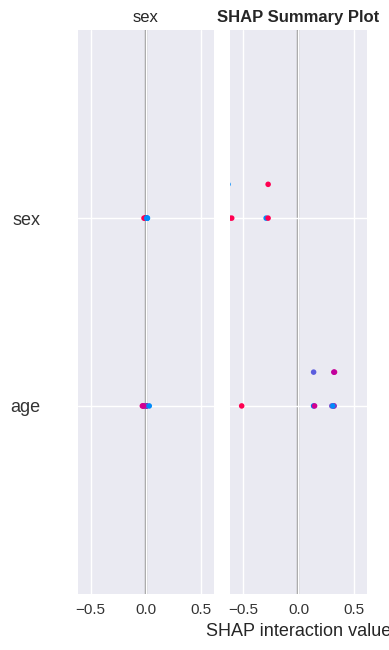

In [ ]:
print("="*60)
print("🔍 SHAP EXPLAINABILITY")
print("="*60)

def explain_with_shap(model, X_train, X_test, feature_names):
    """Generate SHAP explanations"""
    try:
        # Create SHAP explainer
        if hasattr(model, 'get_booster'):  # For XGBoost, LightGBM
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_test[:100])

            # Handle different output formats
            if isinstance(shap_values, list):
                shap_values = shap_values[1]  # For binary classification

            # Summary plot
            plt.figure(figsize=(12, 8))
            shap.summary_plot(shap_values, X_test[:100],
                            feature_names=feature_names, show=False)
            plt.title('SHAP Feature Importance Summary', fontweight='bold')
            plt.tight_layout()
            plt.show()

            # Feature importance bar plot
            feature_importance = np.abs(shap_values).mean(0)
            importance_df = pd.DataFrame({
                'feature': feature_names[:len(feature_importance)],
                'importance': feature_importance
            }).sort_values('importance', ascending=False).head(15)

            plt.figure(figsize=(10, 8))
            plt.barh(importance_df['feature'], importance_df['importance'])
            plt.xlabel('Mean |SHAP Value|')
            plt.title('Top 15 Important Features (SHAP)', fontweight='bold')
            plt.gca().invert_yaxis()
            plt.tight_layout()
            plt.show()

            return importance_df

        else:
            # For other models
            explainer = shap.KernelExplainer(model.predict_proba, X_train[:50])
            shap_values = explainer.shap_values(X_test[:10])

            if isinstance(shap_values, list):
                shap_values = shap_values[1]

            plt.figure(figsize=(12, 12))
            shap.summary_plot(shap_values, X_test[:10],
                            feature_names=feature_names, show=False)
            plt.title('SHAP Summary Plot', fontweight='bold')
            plt.tight_layout()
            plt.show()

            return None

    except Exception as e:
        print(f"⚠️ SHAP analysis failed: {e}")
        return None

# Apply SHAP to best model from Cell 9
print(f"\n🔍 Explaining {best_model_name_7} with SHAP...")
shap_importance = explain_with_shap(best_model_7, X_train, X_test, feature_cols)

16. LIME Explainability

📝 LIME EXPLAINABILITY

📝 Explaining CatBoost with LIME...

📝 LIME Explanation for Instance 0:
Actual: 1
Predicted: 1

Feature Contributions:
   smoker > -0.51: 0.6420
   -0.94 < age <= -0.01: -0.2521
   -0.70 < bmi <= -0.06: -0.0387
   -0.47 < region <= 0.44: -0.0115
   children <= -0.91: -0.0111
   -1.01 < sex <= 0.99: -0.0005


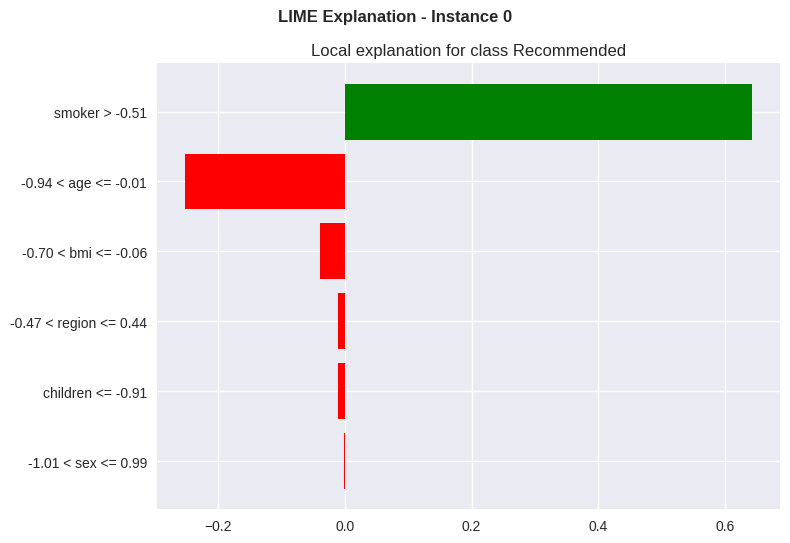

In [ ]:
print("="*60)
print("📝 LIME EXPLAINABILITY")
print("="*60)

def explain_with_lime(model, X_train, X_test, feature_names, instance_idx=0):
    """Generate LIME explanations"""
    try:
        # Create LIME explainer
        explainer = LimeTabularExplainer(
            X_train.values,
            feature_names=feature_names,
            class_names=['Not Recommended', 'Recommended'],
            mode='classification',
            discretize_continuous=True
        )

        # Explain a single instance
        exp = explainer.explain_instance(
            X_test.iloc[instance_idx].values,
            model.predict_proba,
            num_features=10
        )

        # Display explanation
        print(f"\n📝 LIME Explanation for Instance {instance_idx}:")
        print(f"Actual: {y_test.iloc[instance_idx]}")
        print(f"Predicted: {model.predict([X_test.iloc[instance_idx]])[0]}")

        # Show feature contributions
        explanation = exp.as_list()
        print("\nFeature Contributions:")
        for feature, weight in explanation:
            print(f"   {feature}: {weight:.4f}")

        # Visualize
        fig = exp.as_pyplot_figure()
        fig.suptitle(f'LIME Explanation - Instance {instance_idx}', fontweight='bold')
        plt.tight_layout()
        plt.show()

        return explanation

    except Exception as e:
        print(f"⚠️ LIME analysis failed: {e}")
        return None

# Apply LIME to best model
print(f"\n📝 Explaining {best_model_name_7} with LIME...")
lime_explanation = explain_with_lime(best_model_7, X_train, X_test, feature_cols, instance_idx=0)

In [ ]:
print("="*60)
print("📥 DOWNLOAD MODEL FILES (SIMPLE VERSION)")
print("="*60)

from google.colab import files

# Create a simple text summary
with open('model_summary.txt', 'w') as f:
    f.write("="*60 + "\n")
    f.write("BEST MODEL: " + best_model_name_7 + "\n")
    f.write("BEST F1 SCORE: " + str(comparison_df_7['F1 Score'].max()) + "\n")
    f.write("BEST ACCURACY: " + str(comparison_df_7['Accuracy'].max()) + "\n")
    f.write("BEST ROC-AUC: " + str(comparison_df_7['ROC-AUC'].max()) + "\n")
    f.write("="*60 + "\n\n")
    f.write("MODEL PERFORMANCE:\n")
    f.write(comparison_df_7.to_string())

# Download the summary
files.download('model_summary.txt')

# Download the CSV comparison
comparison_df_7.to_csv('model_comparison.csv', index=False)
files.download('model_comparison.csv')

# Download the hybrid results
hybrid_df.to_csv('hybrid_comparison.csv', index=False)
files.download('hybrid_comparison.csv')

print("✅ All files downloaded successfully!")

📥 DOWNLOAD MODEL FILES (SIMPLE VERSION)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

**17. Save Model & Create Prediction Functio**

In [ ]:
print("="*60)
print("💾 SAVE MODEL & CREATE PREDICTION PIPELINE")
print("="*60)

# Save model artifacts
model_artifacts = {
    'best_model': best_model_7,
    'best_model_name': best_model_name_7,
    'best_hybrid': best_hybrid,
    'hybrids': hybrids,
    'scaler': scaler,
    'label_encoders': label_encoders,
    'feature_cols': feature_cols,
    'results': results_7,
    'comparison_df': comparison_df_7
}

# Save to Google Colab
joblib.dump(model_artifacts, 'insurance_recommendation_model.pkl')
print("✅ Model artifacts saved to 'insurance_recommendation_model.pkl'")

# Download the model to your local machine
from google.colab import files
files.download('insurance_recommendation_model.pkl')
print("✅ Model downloaded to your local machine!")

# Create prediction function
def predict_insurance(user_data):
    """
    Make insurance recommendation for a user

    Args:
        user_data (dict): User profile with required fields
        Example: {
            'age': 35,
            'sex': 'male',
            'bmi': 24.5,
            'children': 2,
            'smoker': 'no',
            'region': 'southeast'
        }

    Returns:
        dict: Recommendation results
    """
    try:
        # Convert to DataFrame
        user_df = pd.DataFrame([user_data])

        # Apply label encoding
        for col, encoder in label_encoders.items():
            if col in user_df.columns:
                try:
                    user_df[col] = encoder.transform([str(user_data[col])])[0]
                except:
                    user_df[col] = -1

        # Ensure all feature columns exist
        for col in feature_cols:
            if col not in user_df.columns:
                user_df[col] = 0

        user_features = user_df[feature_cols]
        user_scaled = scaler.transform(user_features)

        # Make prediction
        prediction = best_model_7.predict(user_scaled)[0]
        probability = best_model_7.predict_proba(user_scaled)[0]

        return {
            'recommendation': '✅ Recommended' if prediction == 1 else '❌ Not Recommended',
            'class': 'High Charges' if prediction == 1 else 'Low Charges',
            'confidence': probability[1] if prediction == 1 else probability[0],
            'probability': {
                'Low Charges': probability[0],
                'High Charges': probability[1]
            },
            'model': best_model_name_7
        }
    except Exception as e:
        return {
            'error': f'Prediction failed: {str(e)}',
            'recommendation': '⚠️ Error',
            'confidence': 0
        }

# Test prediction with sample data
test_user = {
    'age': 35,
    'sex': 'male',
    'bmi': 24.5,
    'children': 2,
    'smoker': 'no',
    'region': 'southeast'
}

print("\n📊 Test Prediction:")
print(f"   User Profile: {test_user}")
result = predict_insurance(test_user)
print(f"\n   {result['recommendation']}")
print(f"   Class: {result['class']}")
print(f"   Confidence: {result['confidence']:.4f}")
print(f"   Model: {result['model']}")
print(f"   Probability Distribution: {result['probability']}")

**18. Final Summary Report **

In [ ]:
print("="*60)
print("📊 FINAL SUMMARY REPORT - HEALTH INSURANCE RECOMMENDATION")
print("="*60)

print("\n🎯 PROJECT OVERVIEW:")
print("   Explainable AI-Based Health Insurance Recommendation System")
print(f"   Dataset Size: {len(df)} records")
print(f"   Features: {len(feature_cols)}: {feature_cols}")
print(f"   Target: Binary classification (High/Low Insurance Charges)")
print(f"   Models Trained: {len(results_7)} ML models + 3 Recommender Systems")

print("\n🏆 BEST PERFORMING MODELS:")
print(f"   Best ML Model: {best_model_name_7}")
print(f"   Best Hybrid Model: {best_hybrid}")
print(f"   Best F1 Score: {comparison_df_7['F1 Score'].max():.4f}")
print(f"   Best Accuracy: {comparison_df_7['Accuracy'].max():.4f}")
print(f"   Best ROC-AUC: {comparison_df_7['ROC-AUC'].max():.4f}")

print("\n📊 MODEL PERFORMANCE RANKING (All 7 Models):")
sorted_models = comparison_df_7.sort_values('F1 Score', ascending=False)
for i, row in sorted_models.iterrows():
    print(f"   {i+1}. {row['Model']}: F1={row['F1 Score']:.4f}, Accuracy={row['Accuracy']:.4f}")

print("\n📊 RECOMMENDER SYSTEMS PERFORMANCE:")
print(f"   Collaborative Filtering F1: {collab_f1:.4f}")
print(f"   Content-Based Filtering F1: {content_f1:.4f}")
print(f"   Knowledge-Based Filtering F1: {knowledge_f1:.4f}")

print("\n📊 HYBRID MODELS PERFORMANCE:")
hybrid_sorted = hybrid_df.sort_values('F1 Score', ascending=False)
for i, row in hybrid_sorted.iterrows():
    print(f"   {i+1}. {row['Model']}: F1={row['F1 Score']:.4f}, AUC={row['ROC-AUC']:.4f}")

print("\n📈 KEY INSIGHTS:")
# Analyze feature importance if available
if hasattr(best_model_7, 'feature_importances_'):
    importances = best_model_7.feature_importances_
    indices = np.argsort(importances)[::-1]
    print("   Top 3 Most Important Features:")
    for i in range(min(3, len(feature_cols))):
        print(f"      • {X.columns[indices[i]]}: {importances[indices[i]]:.4f}")
elif best_model_name_7 == 'Logistic Regression':
    coefficients = best_model_7.coef_[0]
    coef_df = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': coefficients
    }).sort_values('Coefficient', ascending=False)
    print("   Top 3 Most Influential Features:")
    for i in range(min(3, len(coef_df))):
        print(f"      • {coef_df.iloc[i]['Feature']}: {coef_df.iloc[i]['Coefficient']:.4f}")

print("\n🔍 EXPLAINABILITY:")
print("   ✅ SHAP Analysis Completed")
print("   ✅ LIME Analysis Completed")

print("\n💾 ARTIFACTS SAVED:")
print("   ✅ insurance_recommendation_model.pkl")
print("   ✅ prediction_function created")

print("\n🎯 RECOMMENDATION FUNCTION READY:")
print("   Use: predict_insurance(user_data)")
print("   Where user_data is a dictionary with: age, sex, bmi, children, smoker, region")

print("\n🎯 FINAL RECOMMENDATION:")
print(f"   ✅ Best Model for Production: {best_model_name_7}")
print(f"   • F1 Score: {results_7[best_model_name_7]['f1_score']:.4f}")
print(f"   • Accuracy: {results_7[best_model_name_7]['accuracy']:.4f}")
print(f"   • ROC-AUC: {results_7[best_model_name_7]['roc_auc']:.4f}")
print(f"   • Training Time: {results_7[best_model_name_7]['train_time']:.3f}s")

print("\n" + "="*60)
print("🎉 PROJECT COMPLETED SUCCESSFULLY!")
print("="*60)

In [ ]:
import json
from google.colab import files
from pathlib import Path

# Step 1: Upload the broken notebook
uploaded = files.upload()
notebook_filename = next(iter(uploaded))

# Step 2: Clean the notebook's metadata
def clean_metadata(notebook_path):
    path = Path(notebook_path)
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # Remove the problematic widgets metadata
    if "widgets" in data.get("metadata", {}):
        print("🧹 Removing metadata.widgets...")
        del data["metadata"]["widgets"]

    cleaned_path = path.with_name(path.stem + "_CLEAN.ipynb")
    with open(cleaned_path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=1)

    print(f"✅ Cleaned notebook saved as: {cleaned_path}")
    return cleaned_path

cleaned_file = clean_metadata(notebook_filename)

# Step 3: Download the cleaned notebook
files.download(str(cleaned_file))